## Import Dataset AG-News


**Dataset** : AG News, yang diakses melalui repositori Hugging Face (wangrongsheng/ag_news).

Dataset ini berisi kumpulan data teks berita yang terdiri dari judul dan deskripsi singkat, yang kemudian diklasifikasikan ke dalam empat kategori utama, yaitu World, Sports, Business, dan Sci/Tech.

In [1]:
!pip install datasets

In [2]:
from datasets import load_dataset

ds = load_dataset("wangrongsheng/ag_news")

print(ds["train"][0])
print(ds["test"][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}
{'text': "Fears for T N pension after talks Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul.", 'label': 2}


In [3]:
import pandas as pd

# Convert ke DataFrame
train_df = pd.DataFrame(ds["train"])
test_df = pd.DataFrame(ds["test"])

# Menampilkan 5 data pertama
display(train_df.head())
display(test_df.head())

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


,text,label
0,Fears for T N pension after talks Unions repre...,2
1,The Race is On: Second Private Team Sets Launc...,3
2,Ky. Company Wins Grant to Study Peptides (AP) ...,3
3,Prediction Unit Helps Forecast Wildfires (AP) ...,3
4,Calif. Aims to Limit Farm-Related Smog (AP) AP...,3


In [4]:
# Melihat jumlah data
print(len(ds["train"]))
print(len(ds["test"]))

120000
7600


In [5]:
# Melihat fitur/kolom
print(ds["train"].features)

{'text': Value('string'), 'label': ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'])}


In [6]:
from collections import Counter

# Melihat statistik label
print(Counter(ds["train"]["label"]))
print(Counter(ds["test"]["label"]))

Counter({2: 30000, 3: 30000, 1: 30000, 0: 30000})
Counter({2: 1900, 3: 1900, 1: 1900, 0: 1900})


## Prepocessing

In [7]:
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from tqdm import tqdm # Digunakan untuk menampilkan progress bar

# Mengunduh resource NLTK
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [8]:
# PRE-CHECKS
def data_quality_check(df, split_name="Dataset"):
    print(f"=== Pengecekan Kualitas {split_name} ===")
    print(f"Total baris awal: {len(df)}")

    # Cek Missing Values
    missing = df['text'].isnull().sum()
    print(f"Missing values pada kolom 'text': {missing}")

    # Cek Duplikat
    duplicates = df.duplicated(subset=['text']).sum()
    print(f"Data duplikat: {duplicates}")
    print("-" * 30)

    # Membersihkan Missing Values & Duplikat jika ada
    if missing > 0:
        df = df.dropna(subset=['text'])
    if duplicates > 0:
        df = df.drop_duplicates(subset=['text'])

    return df.reset_index(drop=True)

# Lakukan pengecekan pada train_df dan test_df
train_df = data_quality_check(train_df, "Data Train")
test_df = data_quality_check(test_df, "Data Test")

=== Pengecekan Kualitas Data Train ===
Total baris awal: 120000
Missing values pada kolom 'text': 0
Data duplikat: 0
------------------------------
=== Pengecekan Kualitas Data Test ===
Total baris awal: 7600
Missing values pada kolom 'text': 0
Data duplikat: 0
------------------------------


In [9]:
# Inisialisasi daftar stopword bahasa Inggris
stop_words_eng = set(stopwords.words('english'))

def preprocess_text(text):
    # Memastikan input adalah string
    text = str(text)

    # ---------------------------------------------------
    # TAHAP 1: Data Cleaning
    # ---------------------------------------------------

    # Menghapus URL/Link
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Menghapus tag HTML
    text = re.sub(r'<.*?>', '', text)
    # Menghapus karakter spesial, angka, dan tanda baca (hanya menyisakan huruf alfabet)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # Menghapus spasi ganda
    text = re.sub(r'\s+', ' ', text).strip()

    # ---------------------------------------------------
    # TAHAP 2: Case Folding
    # ---------------------------------------------------
    # Mengubah semua huruf menjadi huruf kecil
    text = text.lower()

    # ---------------------------------------------------
    # TAHAP 3: Tokenization
    # ---------------------------------------------------
    # Memecah teks menjadi token/kata
    tokens = word_tokenize(text)

    # ---------------------------------------------------
    # TAHAP 4: Stopword Removal
    # ---------------------------------------------------
    # Memfilter token yang bukan merupakan stopword
    filtered_tokens = [word for word in tokens if word not in stop_words_eng]

    # Menggabungkan token kembali menjadi satu string untuk persiapan TF-IDF & SVM
    cleaned_text = " ".join(filtered_tokens)

    return cleaned_text

In [10]:
# Mengaktifkan tqdm untuk pandas
tqdm.pandas(desc="Preprocessing Progress")

# Mengaplikasikan fungsi pada Data Train
print("Memulai preprocessing untuk Data Train...")
train_df['clean_text'] = train_df['text'].progress_apply(preprocess_text)

# Mengaplikasikan fungsi pada Data Test
print("Memulai preprocessing untuk Data Test...")
test_df['clean_text'] = test_df['text'].progress_apply(preprocess_text)

# Menampilkan hasil perbandingan sebelum dan sesudah preprocessing
print("\nHasil Preprocessing Data Train (5 Data Pertama):")
display(train_df[['text', 'clean_text']].head())

Memulai preprocessing untuk Data Train...


Preprocessing Progress: 100%|██████████| 120000/120000 [00:20<00:00, 5885.55it/s]


Memulai preprocessing untuk Data Test...


Preprocessing Progress: 100%|██████████| 7600/7600 [00:01<00:00, 4586.75it/s]


Hasil Preprocessing Data Train (5 Data Pertama):


,text,clean_text
0,Wall St. Bears Claw Back Into the Black (Reute...,wall st bears claw back black reuters reuters ...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle looks toward commercial aerospace reut...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil economy cloud stocks outlook reuters reute...
3,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halts oil exports main southern pipeline ...
4,"Oil prices soar to all-time record, posing new...",oil prices soar time record posing new menace ...


# Teks Representation

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Inisialisasi TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,  # Membatasi hanya 10.000 kata dengan frekuensi tertinggi
    min_df=5,            # Mengabaikan kata yang muncul di kurang dari 5 dokumen (biasanya typo/noise)
    max_df=0.8           # Mengabaikan kata yang muncul di lebih dari 80% dokumen (terlalu umum)
)

# 2. Fit dan Transform pada Data Latih (Train)
# fit_transform: Mempelajari kosa kata dari data train sekaligus mengubahnya menjadi matriks
X_train = tfidf_vectorizer.fit_transform(train_df['clean_text'])

# 3. Transform pada Data Uji (Test)
# Untuk memastikan model tidak mempelajari kosa kata baru dari data test (mencegah data leakage).
X_test = tfidf_vectorizer.transform(test_df['clean_text'])

# 4. Memisahkan Label/Target
y_train = train_df['label'].values
y_test = test_df['label'].values

print("Proses Text Representation selesai!")
print(f"Dimensi matriks X_train (Fitur): {X_train.shape}")
print(f"Dimensi matriks X_test (Fitur): {X_test.shape}")
print(f"Dimensi y_train (Label): {y_train.shape}")
print(f"Dimensi y_test (Label): {y_test.shape}")

Proses Text Representation selesai!
Dimensi matriks X_train (Fitur): (120000, 10000)
Dimensi matriks X_test (Fitur): (7600, 10000)
Dimensi y_train (Label): (120000,)
Dimensi y_test (Label): (7600,)


## Training & Evaluasi Model

In [12]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

# 1. Inisialisasi Model
svm_model = LinearSVC(random_state=42, dual=False)

# 2. Melatih (Training) Model
start_time = time.time() # Menghitung waktu training

svm_model.fit(X_train, y_train)

end_time = time.time()
print(f"Training selesai dalam waktu {end_time - start_time:.2f} detik!")

# 3. Melakukan Prediksi pada Data Uji (Test Data)
y_pred = svm_model.predict(X_test)

# 4. Evaluasi Model
print("\n=== Evaluasi Model ===")

# Menghitung Akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%\n")

# Menampilkan Laporan Klasifikasi Detail (Precision, Recall, F1-Score)
# (Target names disesuaikan dengan label asli ag_news: 1-World, 2-Sports, 3-Business, 4-Sci/Tech)
target_names = ['World (1)', 'Sports (2)', 'Business (3)', 'Sci/Tech (4)']
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Training selesai dalam waktu 6.56 detik!

=== Evaluasi Model ===
Akurasi Model: 91.30%

Classification Report:
              precision    recall  f1-score   support

   World (1)       0.93      0.90      0.92      1900
  Sports (2)       0.95      0.98      0.97      1900
Business (3)       0.88      0.88      0.88      1900
Sci/Tech (4)       0.88      0.89      0.89      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



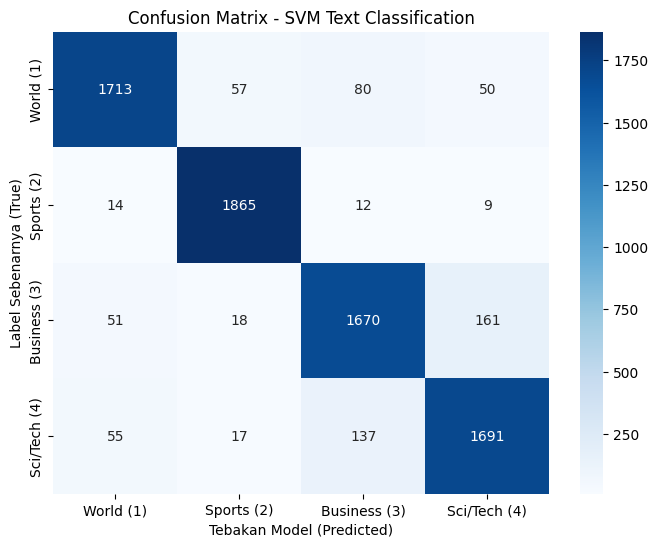

In [13]:
# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - SVM Text Classification')
plt.ylabel('Label Sebenarnya (True)')
plt.xlabel('Tebakan Model (Predicted)')
plt.show()

=== Visualisasi Distribusi Aktual vs Prediksi ===


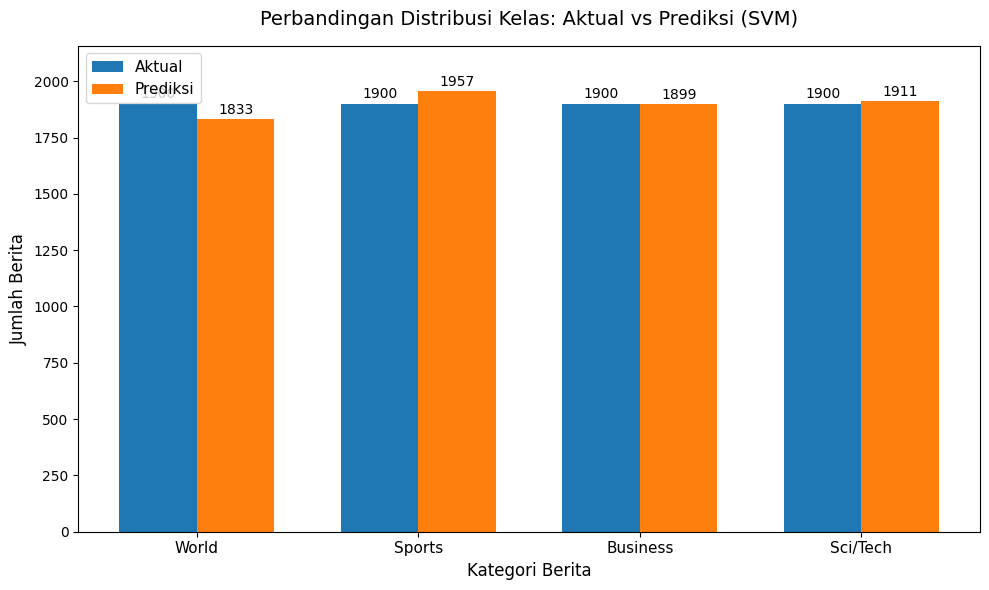

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=== Visualisasi Distribusi Aktual vs Prediksi ===")

# Menghitung jumlah per kelas untuk data Aktual dan Prediksi
actual_counts = pd.Series(y_test).value_counts().sort_index()
pred_counts = pd.Series(y_pred).value_counts().sort_index()

# Mengatur posisi sumbu x dan lebar batang
x = np.arange(len(actual_counts))
width = 0.35

plt.figure(figsize=(10, 6))

# Membuat bar chart berdampingan
bars1 = plt.bar(x - width/2, actual_counts, width, label='Aktual', color='#1f77b4')
bars2 = plt.bar(x + width/2, pred_counts, width, label='Prediksi', color='#ff7f0e')

# Menambahkan label angka persis di atas setiap batang grafik
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height + 10, # Tambah 10 agar teks tidak menempel pada garis batang
                 int(height),
                 ha='center',
                 va='bottom',
                 fontsize=10)

# Kustomisasi tampilan grafik agar lebih profesional
kategori_labels = ['World', 'Sports', 'Business', 'Sci/Tech']
plt.title('Perbandingan Distribusi Kelas: Aktual vs Prediksi (SVM)', fontsize=14, pad=15)
plt.xlabel('Kategori Berita', fontsize=12)
plt.ylabel('Jumlah Berita', fontsize=12)
plt.xticks(x, kategori_labels, fontsize=11)
plt.ylim(0, max(actual_counts.max(), pred_counts.max()) + 200) # Memberi ruang ekstra di atas grafik
plt.legend(fontsize=11)

# Menampilkan grafik yang bersih
plt.tight_layout()
plt.show()

In [14]:
# 1. Membuat mapping kategori agar outputnya berupa teks
kategori_map = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}

# 2. Membuat DataFrame yang berisi teks, label asli, dan hasil prediksi
# Mengasumsikan array y_pred sudah ada dari langkah evaluasi sebelumnya
hasil_prediksi_df = pd.DataFrame({
    'Teks Berita': test_df['text'],
    'Label Asli': test_df['label'].map(kategori_map),
    'Prediksi Model': pd.Series(y_pred).map(kategori_map)
})

# 3. Menambahkan kolom indikator apakah tebakan model Benar atau Salah
hasil_prediksi_df['Status'] = np.where(
    hasil_prediksi_df['Label Asli'] == hasil_prediksi_df['Prediksi Model'],
    '✅ Benar',
    '❌ Salah'
)

# 4. Menampilkan 10 sampel data secara acak untuk melihat variasi tebakan
print("\nMenampilkan 10 Sampel Prediksi Acak:")
display(hasil_prediksi_df.sample(n=10, random_state=42))


Menampilkan 10 Sampel Prediksi Acak:


,Teks Berita,Label Asli,Prediksi Model,Status
7094,Fan v Fan: Manchester City-Tottenham Hotspur T...,Sports,Sports,✅ Benar
1017,Paris Tourists Search for Key to 'Da Vinci Cod...,World,Sci/Tech,❌ Salah
2850,Net firms: Don't tax VoIP The Spanish-American...,Sci/Tech,Sci/Tech,✅ Benar
1452,Dependent species risk extinction The global e...,Sci/Tech,Sci/Tech,✅ Benar
457,EDS Is Charter Member of Siebel BPO Alliance (...,Sci/Tech,Sci/Tech,✅ Benar
6256,Campbell 9 Pct. Profit #39;Hmmm Hmmm Good #39...,Business,Business,✅ Benar
6281,"Forgoing stiff upper lip, Charles jousts with ...",World,World,✅ Benar
4999,Profit Plunges at International Game Tech Inte...,Business,Business,✅ Benar
2941,Salvaging Genesis Despite a seemingly calamito...,Sci/Tech,Sci/Tech,✅ Benar
408,Chavez rejects CD as opposition Venezuela #39;...,Business,World,❌ Salah


## Ekspor Model

In [ ]:
import joblib

print("=== Menyimpan Model & Vectorizer ===")
# Menyimpan model SVM
joblib.dump(svm_model, 'svm_agnews_model.pkl')

# Menyimpan aturan TF-IDF
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')

print("Model dan Vectorizer berhasil disimpan!")

=== Menyimpan Model & Vectorizer ===
Model dan Vectorizer berhasil disimpan!
